# **Multiple-objective optimization - WSM and ECM**

<b>Information on group members:</b><br>
1) 156035, Kuba Czech <br>
2) 156045, Wojciech Nagórka

## **1. INTRODUCTION**

Your task is to solve a multiple-objective portfolio optimization problem.
-  Use the basic Markowitz's model from 1952 (see Lecture 1)
-  Solve = construct Pareto front approximations.
-  The dataset is the same as for the portfolio game part 1 (bundle1.zip).
-  The dataset consists of the historical prices of 20 assets.
-  The bundle contains 20 files (*.txt) linked to different assets.
-  The name of the file suggests the asset's name.
-  The structure of every file is as follows:
1.  The first line contains the name of the asset.
2. The second line provides the number of data points N.
3. The following N lines are data points with the structure: time, price.
-  The historical timeline for all assets is time $\in$ [0,100].
-  Future predictions should be calculated for time = 200.

Goal: 
-  Load data, make predictions, and build the model. 
-  Illustrate your predictions (can be done in the jupyter notebook)
-  Then, implement the WSM and ECM methods (see the tutorial on quadratic programming provided below). 
-  Run your implementations for different calculation limits (e.g., the number of weight vectors for WSM). Compare the methods' efficiency in finding unique Pareto optimal solutions. Finally, illustrate generated Pareto fronts.

## **2. Tutorial on the cvxopt library for quadratic programming**

In [3]:
import os
import sys
import numpy as np
from enum import Enum
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.utils import *
from src.plotting import *
from src.prices import *

### **2.1. QP Optimization Problem**

#### General model:

$max$ $\boldsymbol{cx} - \dfrac{1}{2}\boldsymbol{x}^T\boldsymbol{Qx}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{x} \geq \boldsymbol{0}$

#### But the library uses the following form:

$min$ $\boldsymbol{cx} + \dfrac{1}{2}\boldsymbol{x}^T\boldsymbol{Qx}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{Ax} = \boldsymbol{b}$ <br>

#### Example

$min$ $2x^2_1+x_2^2+x_1x_2+x_1+x_2$ <br>
$s.t.$ <br>
$x_1 \geq 0$<br>
$x_2 \geq 0$<br>
$x_1 + x_2 = 1$<br>

#### Hence:

In [ ]:
Q = matrix([ [4.0, 1.0], [1.0, 2.0] ]) # [4, 1] is 1st column, not row!

In [ ]:
c = matrix([1.0, 1.0]) # (1, 2) = dimensions (1 row and 2 columns)

In [ ]:
A = matrix([1.0, 1.0], (1,2)) # (1, 2) = dimensions (1 row and 2 columns)

In [7]:
b = matrix(1.0) 

In [8]:
G = matrix([[-1.0,0.0],[0.0,-1.0]]) # multiplied both sides by -1

In [10]:
h = matrix([0.0,0.0]) # multiplied both sides by -1

In [11]:
solQP=solvers.qp(Q, c, G, h, A, b)

     pcost       dcost       gap    pres   dres
 0:  1.8889e+00  7.7778e-01  1e+00  2e-16  2e+00
 1:  1.8769e+00  1.8320e+00  4e-02  1e-16  6e-02
 2:  1.8750e+00  1.8739e+00  1e-03  1e-16  5e-04
 3:  1.8750e+00  1.8750e+00  1e-05  0e+00  5e-06
 4:  1.8750e+00  1.8750e+00  1e-07  2e-16  5e-08
Optimal solution found.


In [12]:
print(solQP.keys())

dict_keys(['x', 'y', 's', 'z', 'status', 'gap', 'relative gap', 'primal objective', 'dual objective', 'primal infeasibility', 'dual infeasibility', 'primal slack', 'dual slack', 'iterations'])


In [13]:
print(solQP['x'])
print(solQP['primal objective'])

[ 2.50e-01]
[ 7.50e-01]

1.8750000000000182


### **2.2. Solving Linear Programming tasks**

$min$ $\boldsymbol{c}\boldsymbol{x}$ <br>
$s.t.$ <br>
$\boldsymbol{Gx} \leq \boldsymbol{h}$ <br>
$\boldsymbol{Ax} = \boldsymbol{b}$ (optional)

#### Example

$min$ $2x_1+x_2$ <br>
$s.t.$ <br>
$-x_1 +x_2 \leq 1$ <br>
$x_1 + x_2 \geq 2$ <br>
$x_2 \geq 0$<br>
$x_1 - 2x_2 \leq 4$

In [14]:
G = matrix([ [-1.0, -1.0, 0.0, 1.0], [1.0, -1.0, -1.0, -2.0] ])
h = matrix([ 1.0, -2.0, 0.0, 4.0 ])
c = matrix([ 2.0, 1.0 ])
solLP = solvers.lp(c,G,h)  
# OPTIONALLY A and b can be provided (equality constraints) as in solQP=solvers.qp(Q, c, G, h, A, b)

     pcost       dcost       gap    pres   dres   k/t
 0:  2.6471e+00 -7.0588e-01  2e+01  8e-01  2e+00  1e+00
 1:  3.0726e+00  2.8437e+00  1e+00  1e-01  2e-01  3e-01
 2:  2.4891e+00  2.4808e+00  1e-01  1e-02  2e-02  5e-02
 3:  2.4999e+00  2.4998e+00  1e-03  1e-04  2e-04  5e-04
 4:  2.5000e+00  2.5000e+00  1e-05  1e-06  2e-06  5e-06
 5:  2.5000e+00  2.5000e+00  1e-07  1e-08  2e-08  5e-08
Optimal solution found.


In [15]:
print(solLP.keys())

dict_keys(['x', 'y', 's', 'z', 'status', 'gap', 'relative gap', 'primal objective', 'dual objective', 'primal infeasibility', 'dual infeasibility', 'primal slack', 'dual slack', 'residual as primal infeasibility certificate', 'residual as dual infeasibility certificate', 'iterations'])


In [16]:
print(solLP['x'])
print(solLP['primal objective'])

[ 5.00e-01]
[ 1.50e+00]

2.4999999895543077


## **3. Portfolio optimization**

In [5]:
DIR_path = os.path.join(os.getcwd(), '..', 'data', 'Bundle1')
stocks = read_all_files(DIR_path)

### **3.1. Plotting the prices**

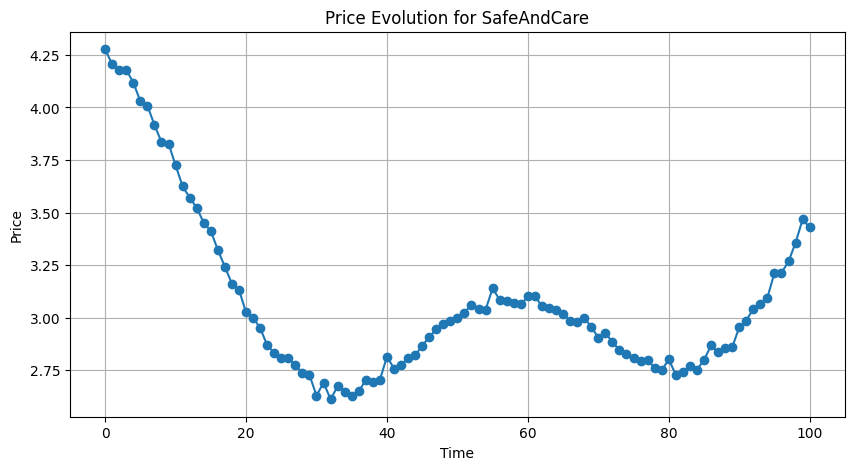

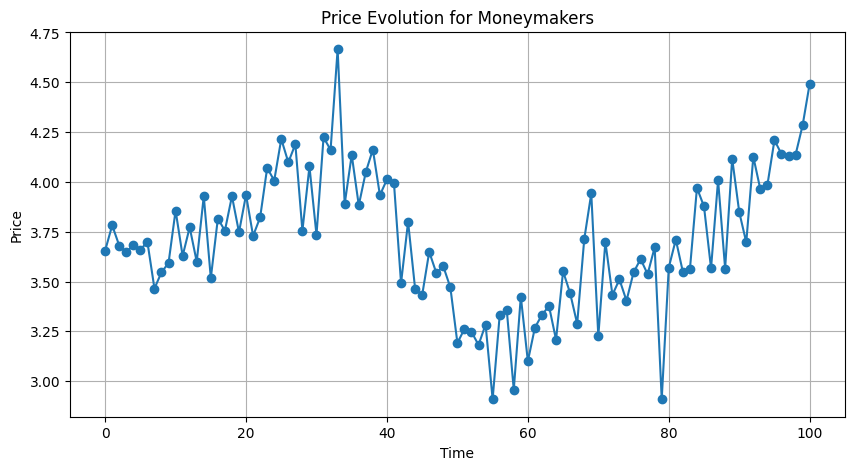

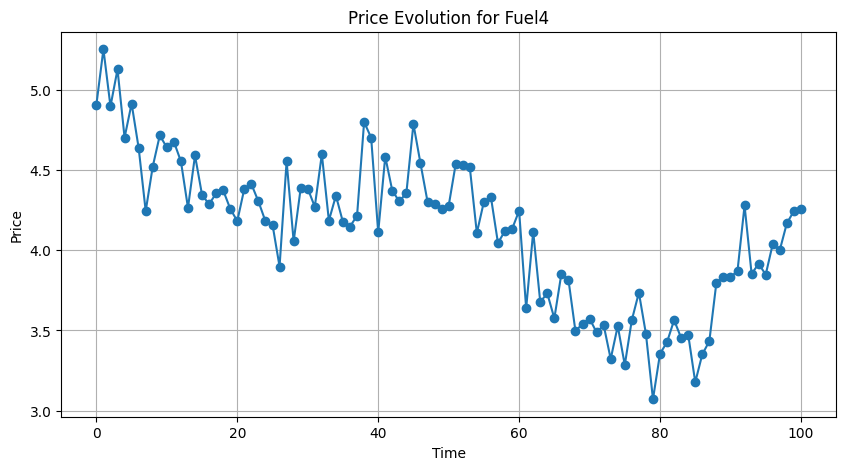

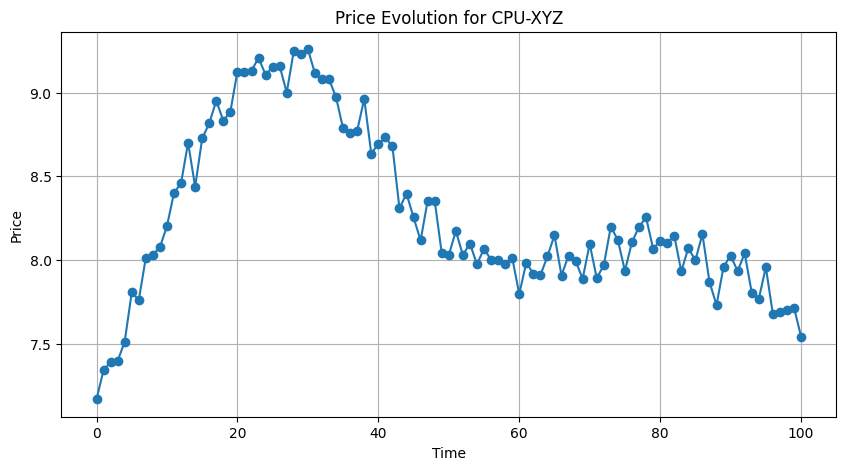

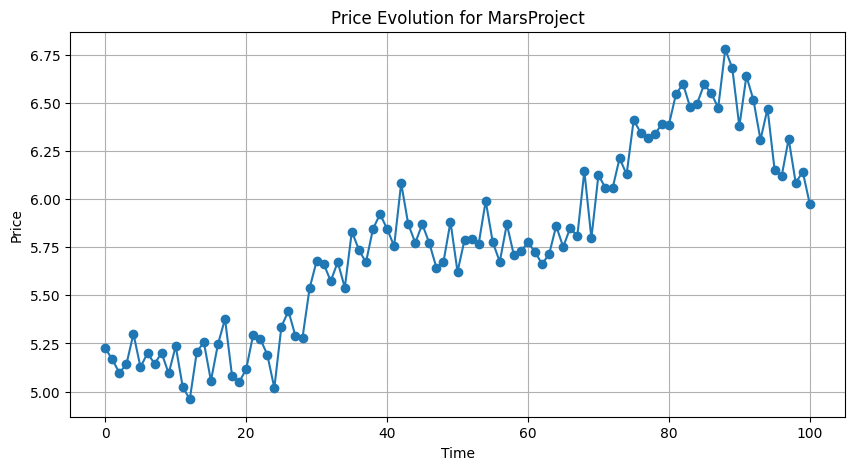

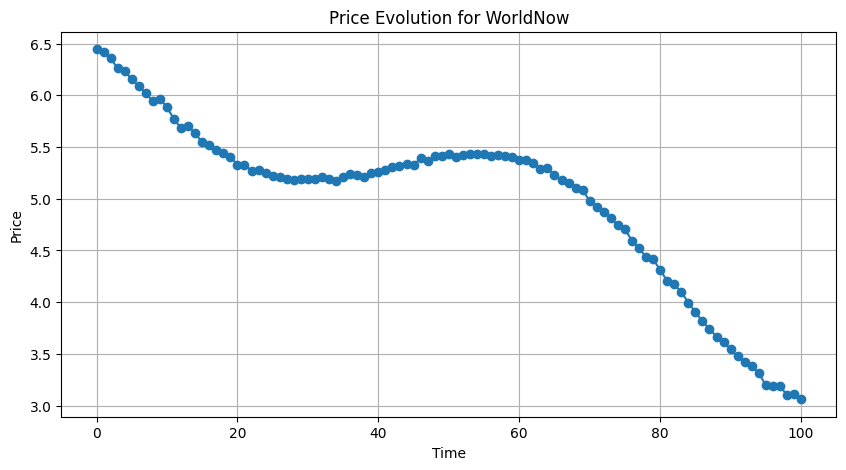

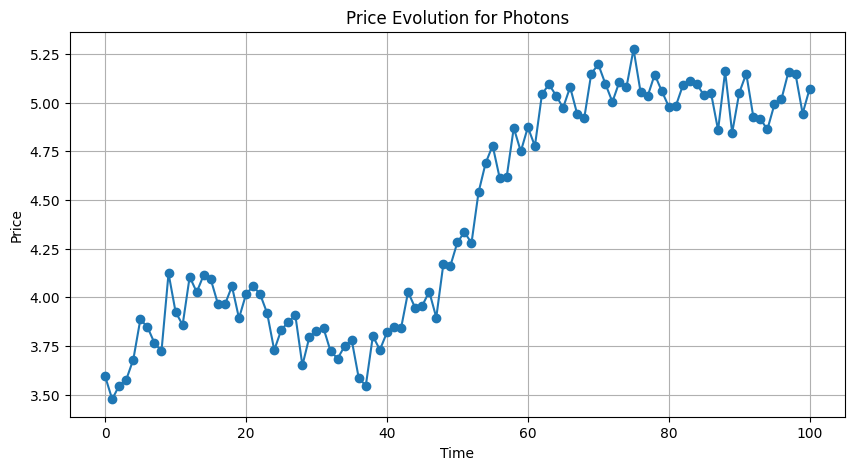

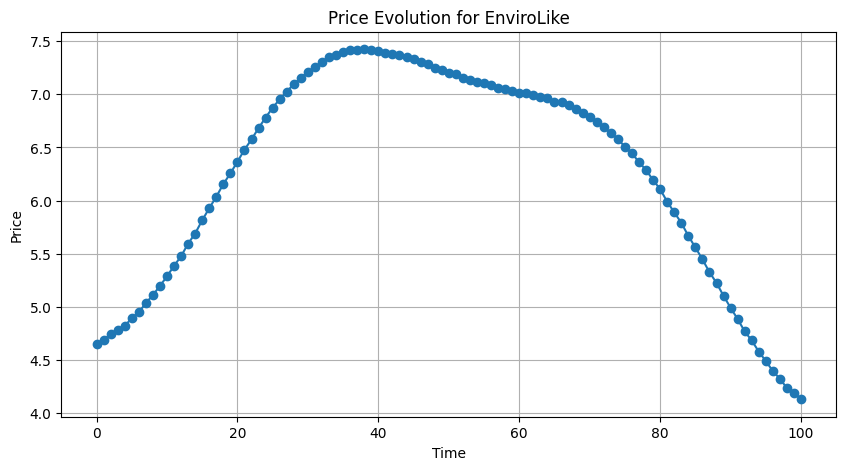

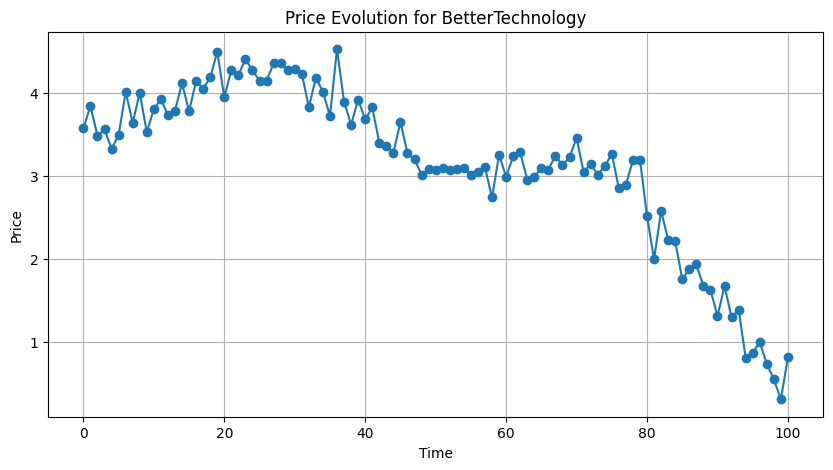

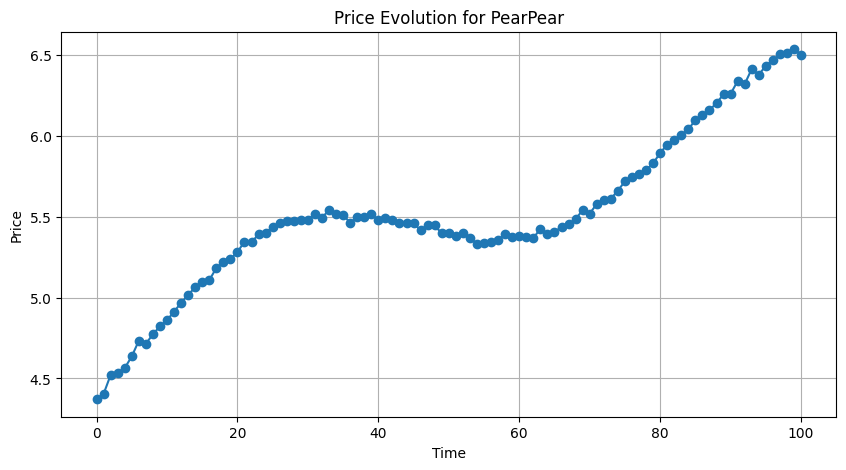

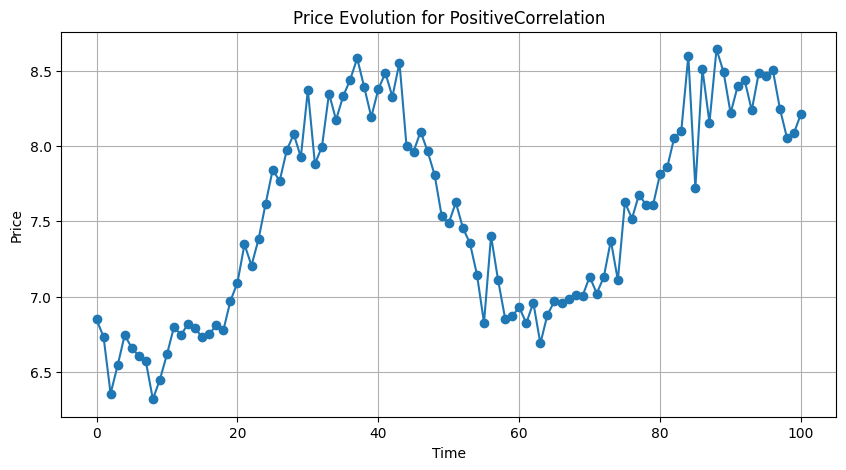

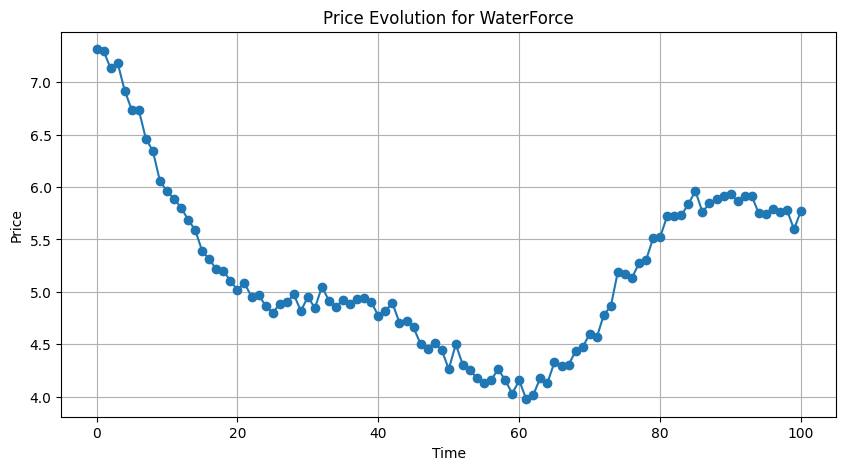

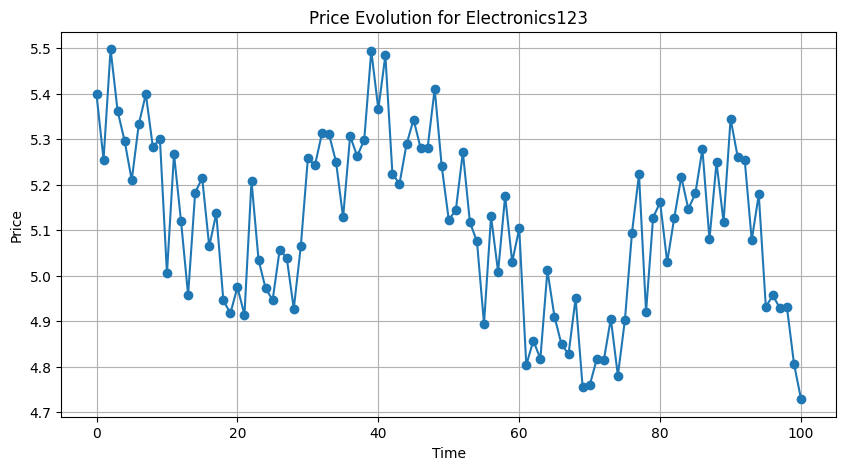

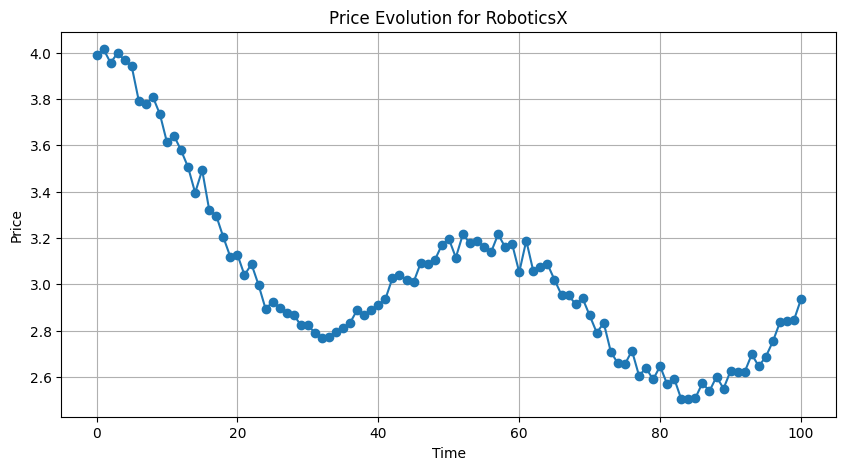

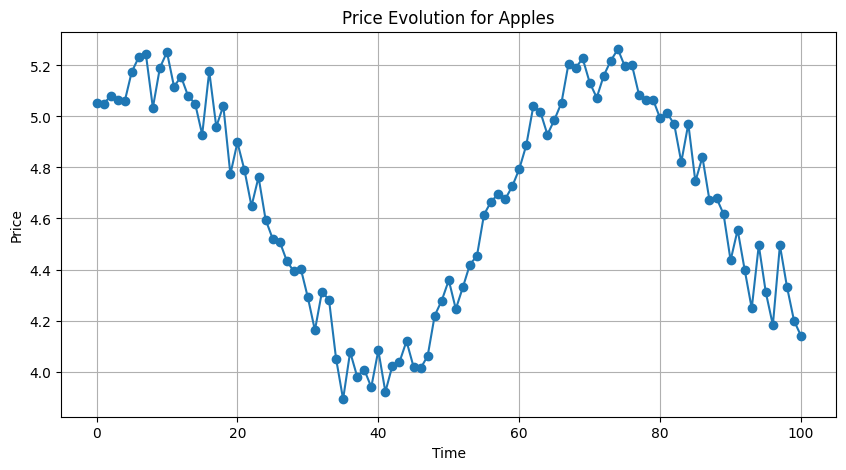

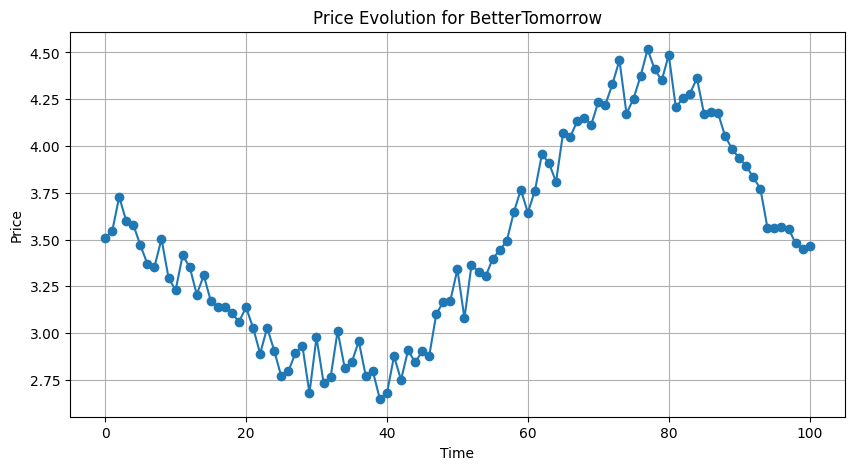

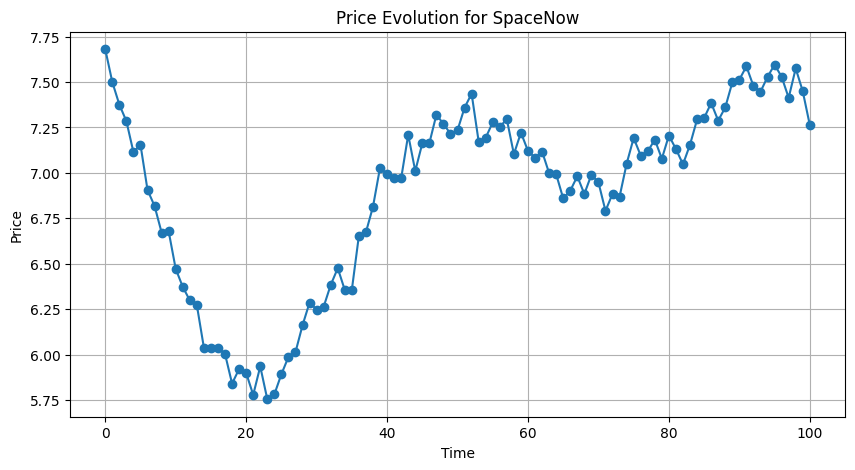

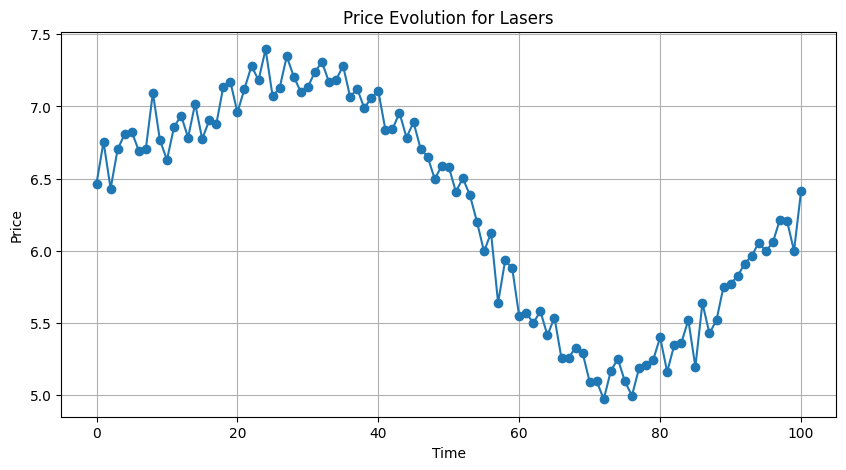

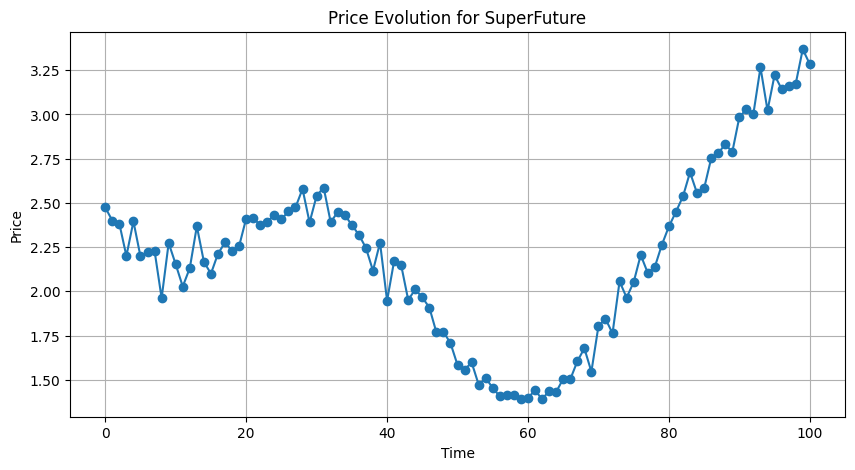

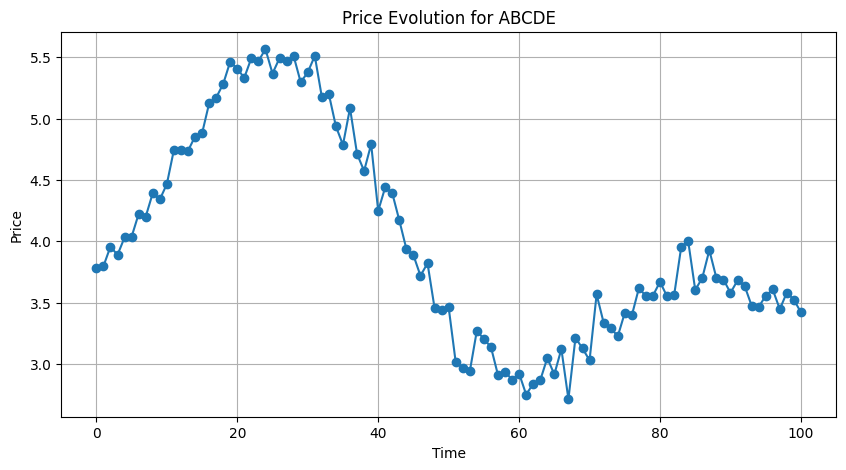

In [6]:
for name, prices in stocks.items():
    plot_prices(name, prices)

### **3.2. Estimating the price**

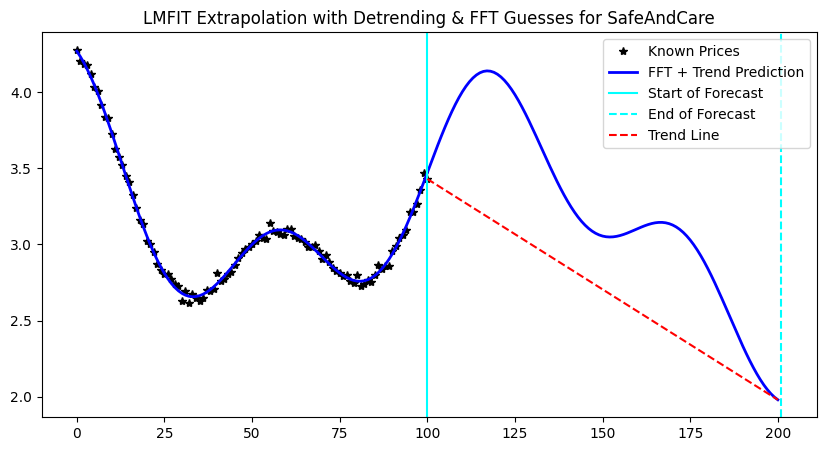

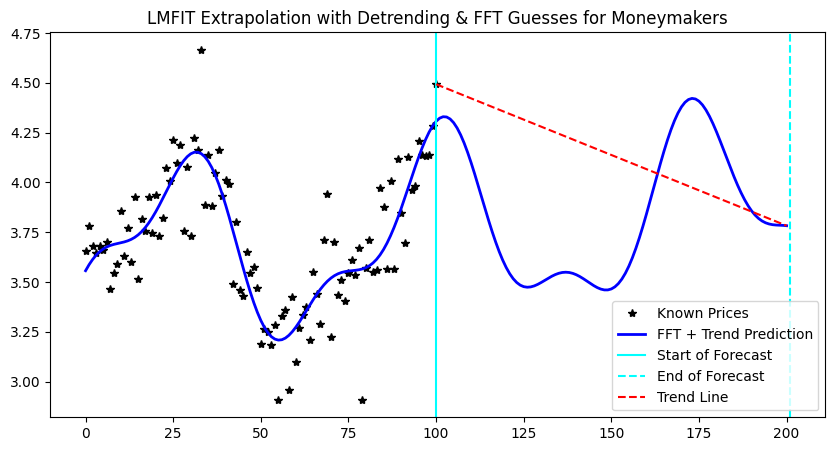

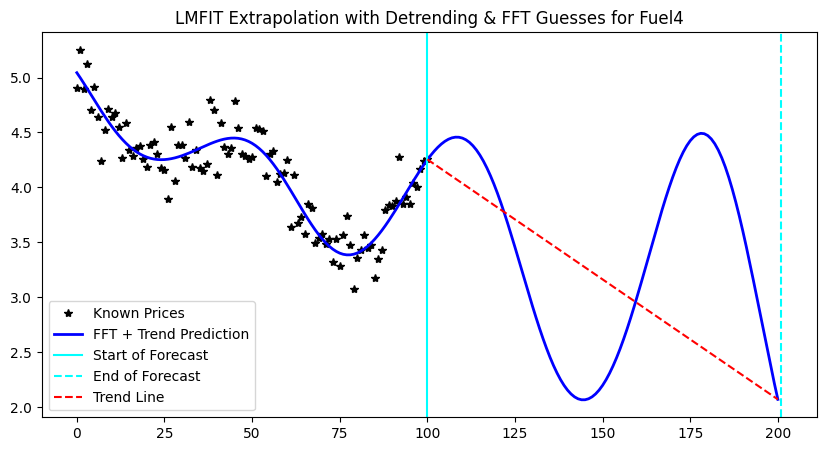

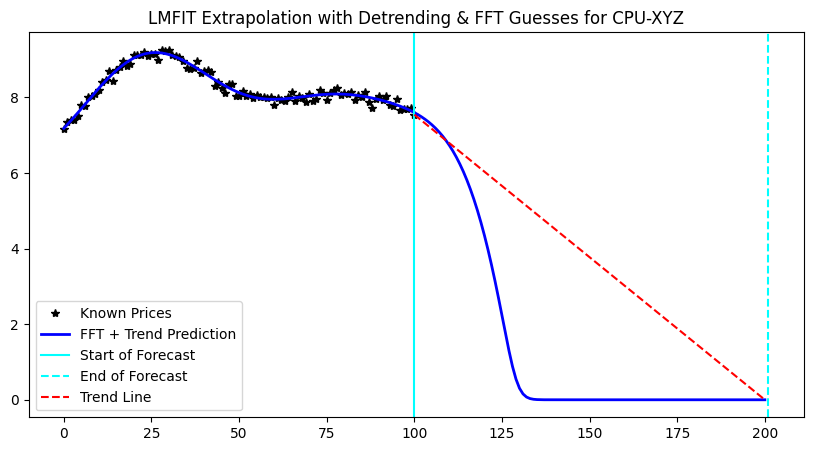

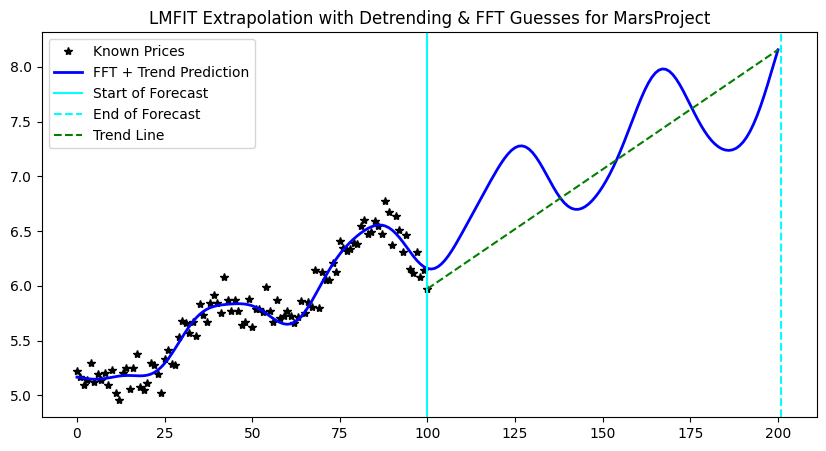

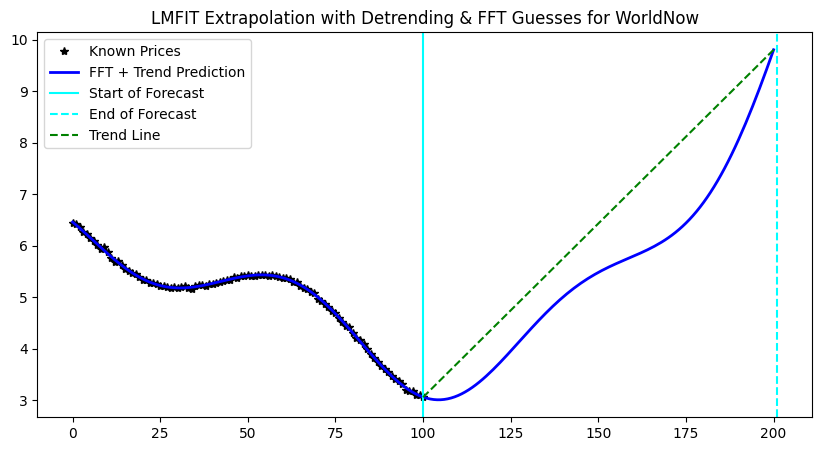

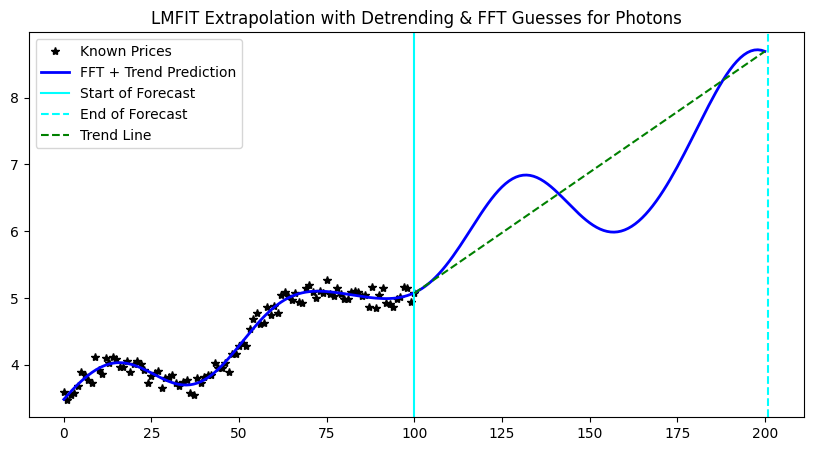

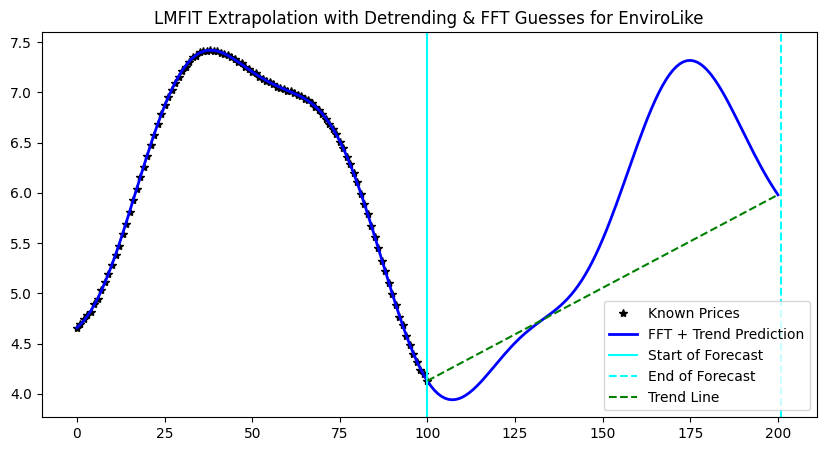

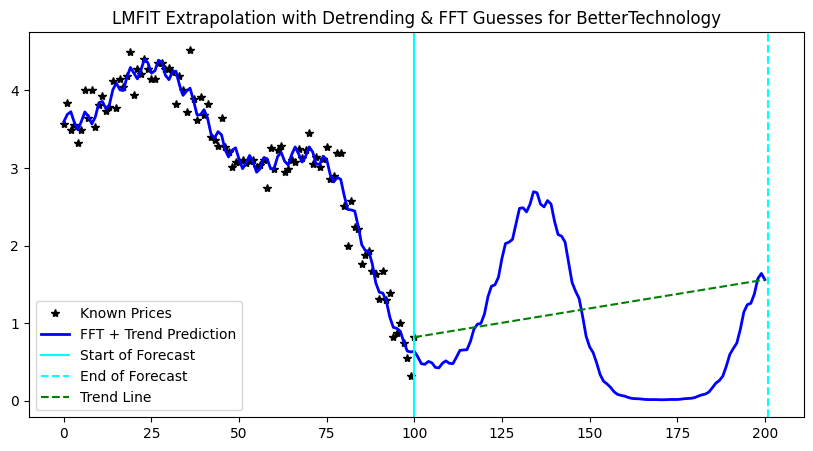

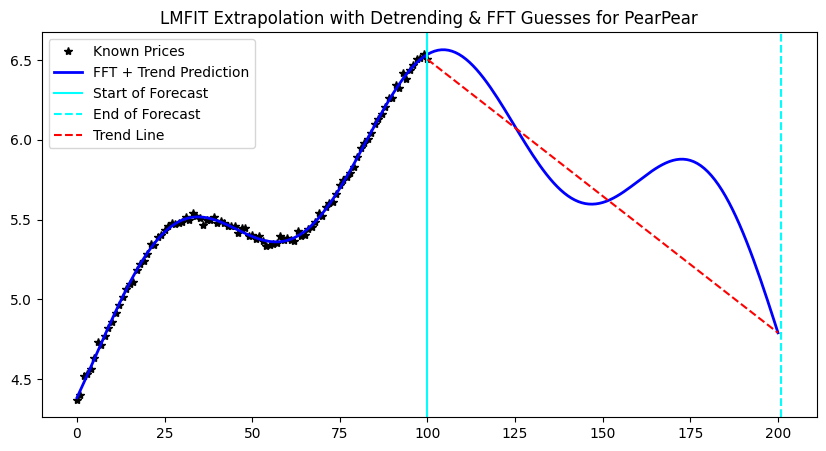

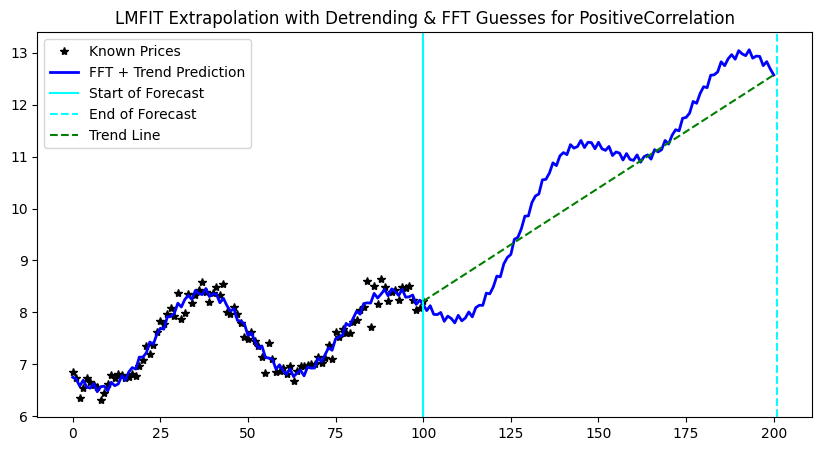

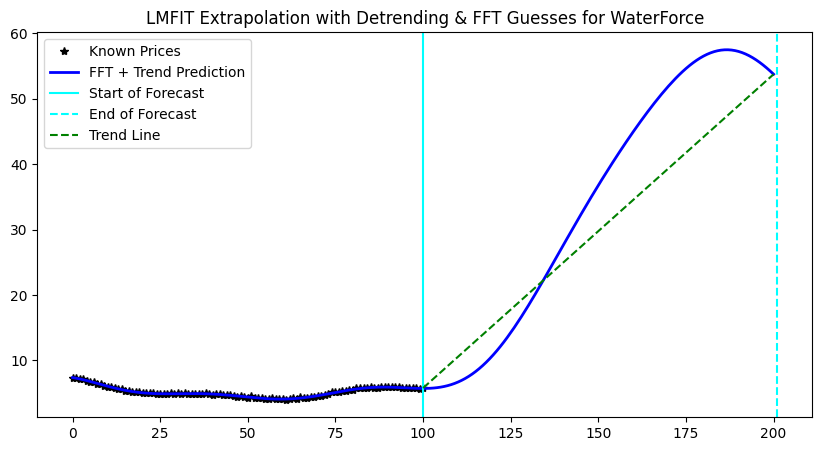

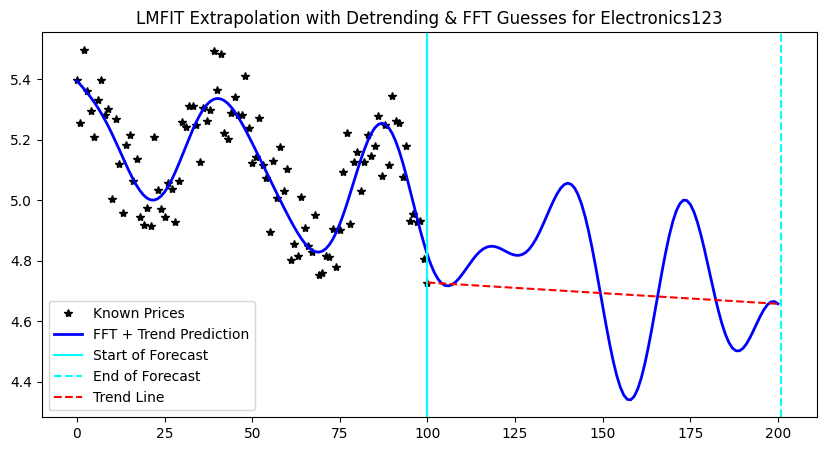

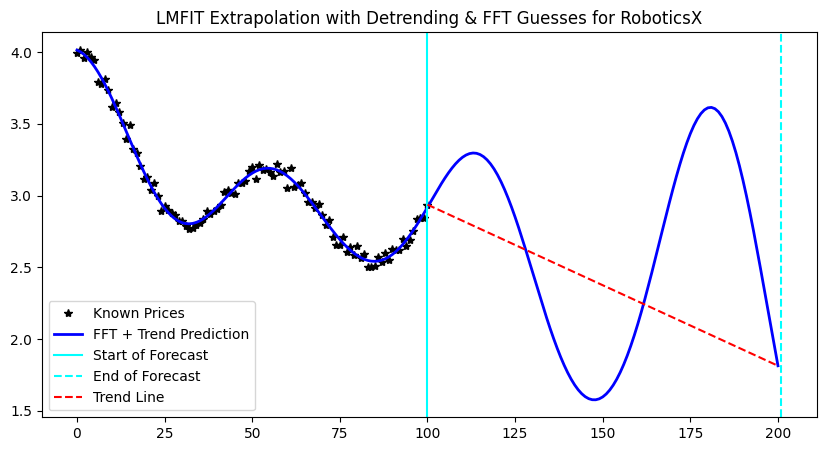

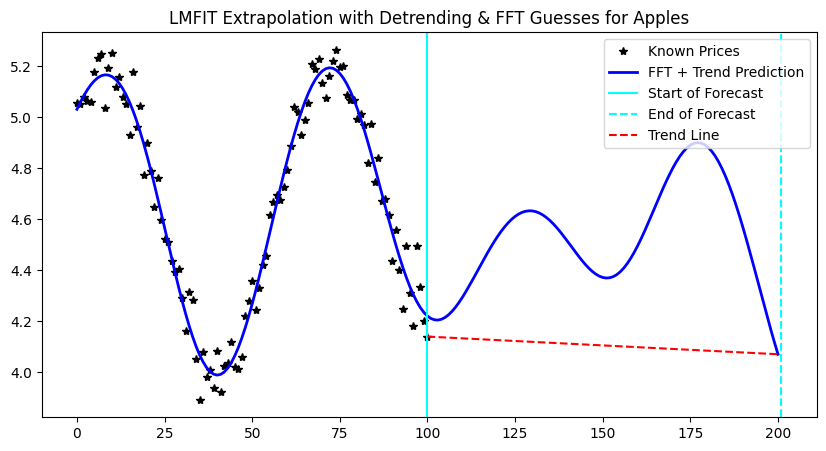

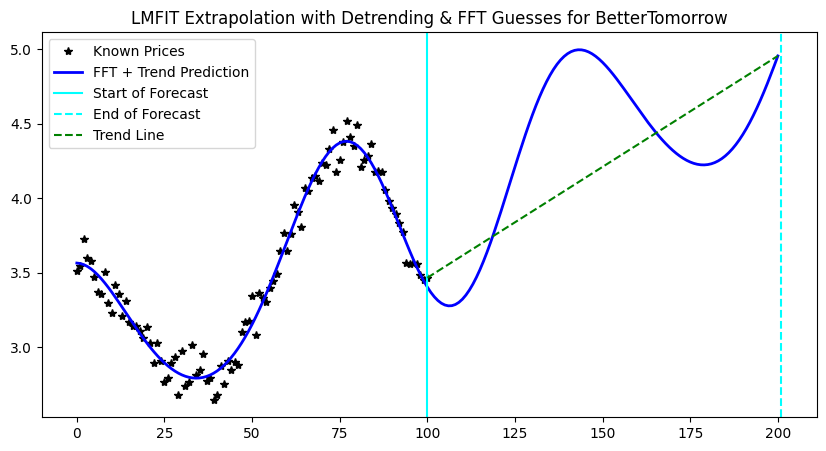

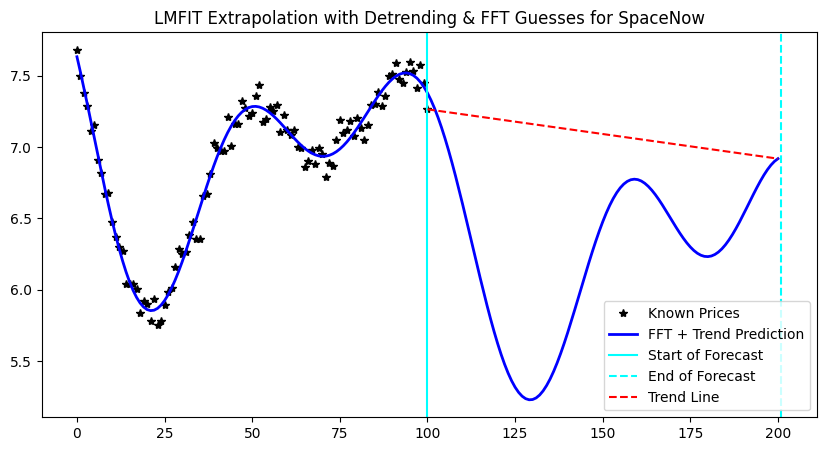

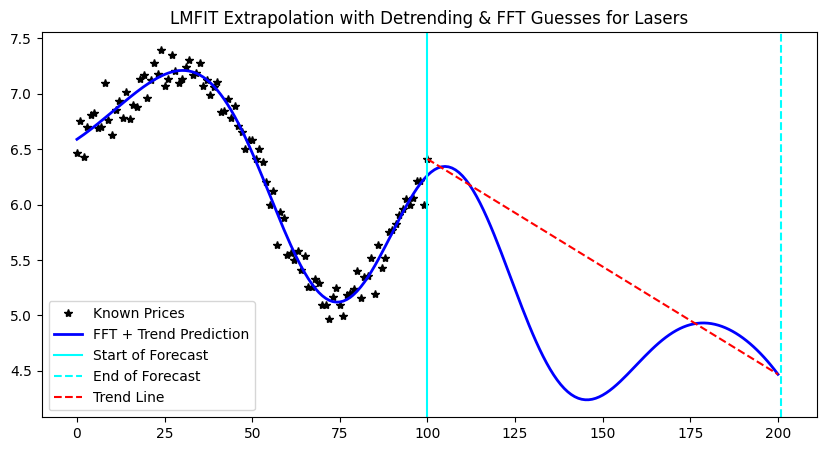

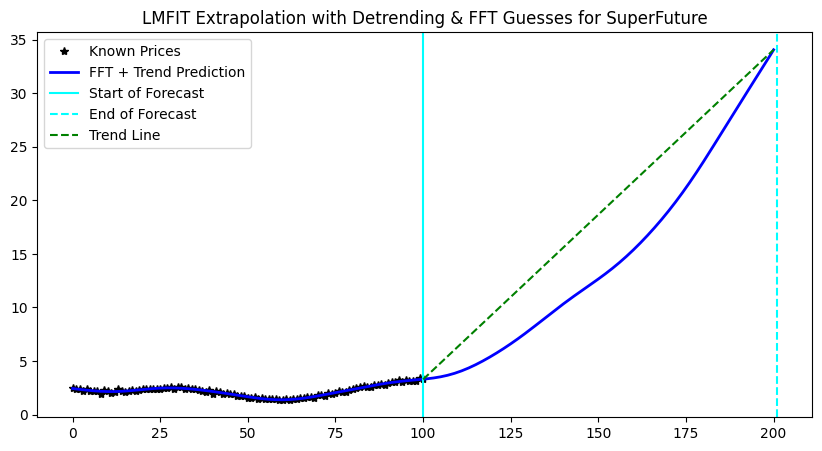

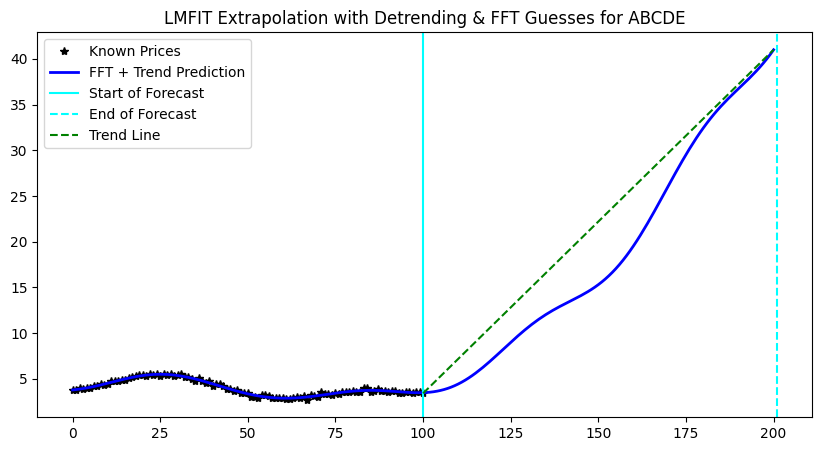

In [7]:
n_sines = 3
returns_at_200 = {}

for key in stocks:
    days_to_train = len(stocks[key])
    x_data = np.arange(days_to_train)
    y_data = stocks[key][:days_to_train]

    x_future, y_future = estimate_price_sum_of_sines(x_data, y_data, n_sines)

    return_200 = (y_future[-1]-y_data[-1])/y_data[-1]
    returns_at_200[key] = return_200
    
    plot_predictions(x_data, y_data, x_future, y_future, name=key)

In [8]:
# Ensure alphabetical order
prices_matrix = np.array([i[1] for i in sorted(stocks.items(), key=lambda x: x[0])])
ratios_matrix = calculate_ratios(prices_matrix)

### **3.3. Estimating the risk**

In [9]:
expected_returns = np.array([i[1] for i in sorted(returns_at_200.items(), key=lambda x: x[0])])
risks_matrix = estimate_risk(ratios_matrix)

### **3.4. Weighted Sum Method (WSM)**

In [ ]:
from src.optimizers import WeightedSumMethodOptimizer

### **3.5. Epsilon Constraint Method (ECM)**

In [ ]:
from src.optimizers import EpsilonConstraintMethodOptimizer

### **4. Portfolio Optimization Game - WSM and ECM**

#### **4.1. Weighted Sum Method**

##### 4.1.1. Plotting Pareto Front for different number of points:

Number of points in the Pareto Front: 11


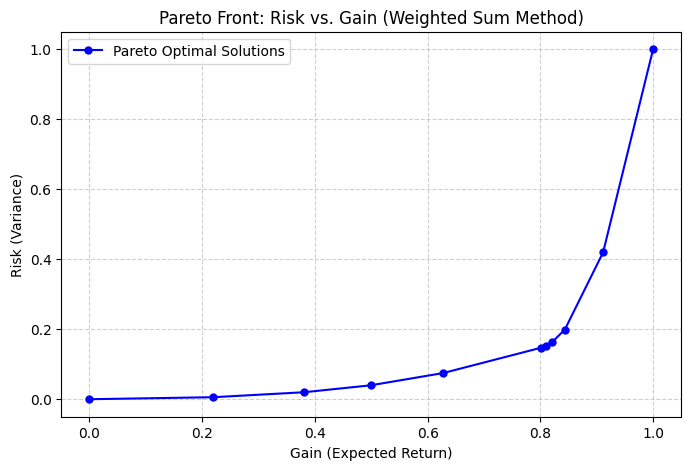

Number of points in the Pareto Front: 21


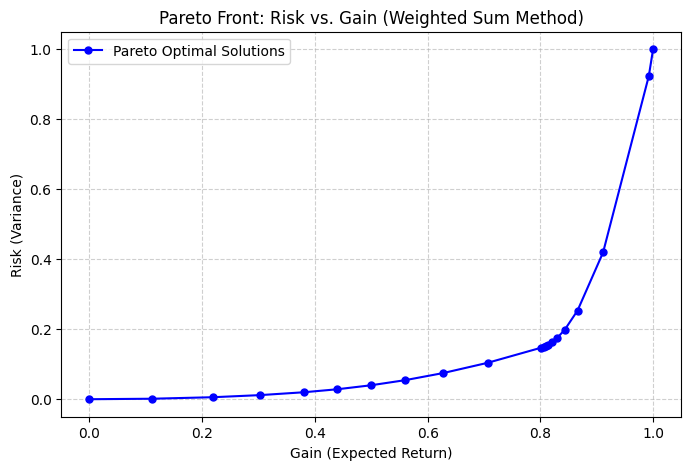

Number of points in the Pareto Front: 51


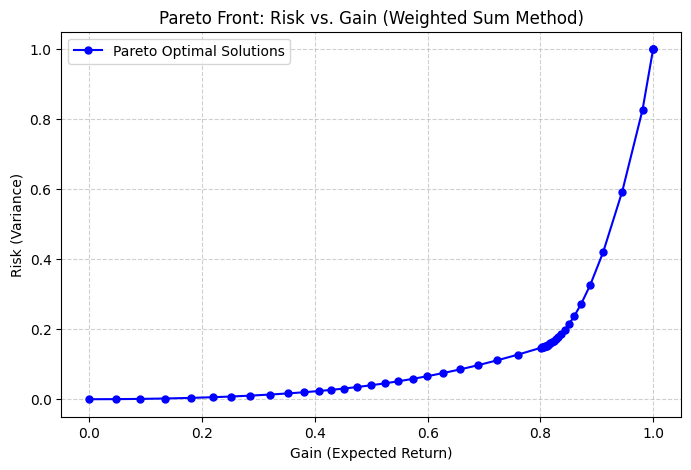

Number of points in the Pareto Front: 101


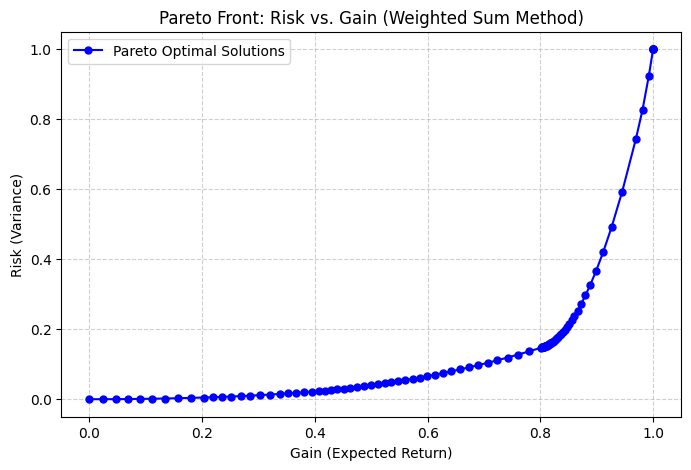

Number of points in the Pareto Front: 201


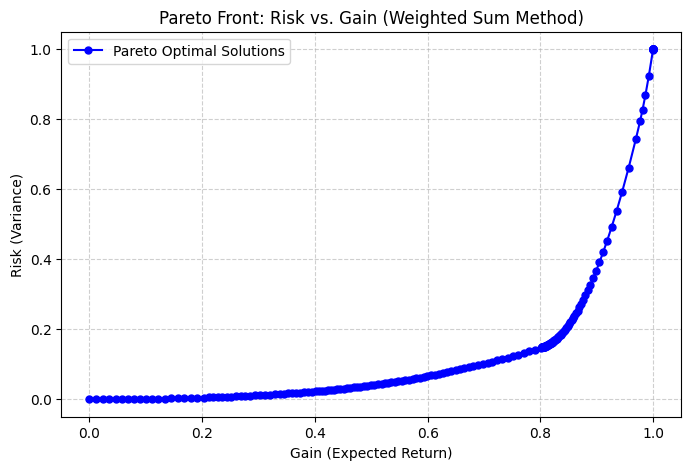

In [13]:
for n_ in [11, 21, 51, 101, 201]:
    WSM = WeightedSumMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
    wsm_pareto_front, weights = WSM.optimize()
    print(f'Number of points in the Pareto Front: {n_}')
    WSM.plot_pareto_front()

Front with 10 points looks like poor visualization, however Pareto Front with 200 (and also 100) points looks too crowded. All the Fronts have the most points located close to gain of approximately 0.85.

##### 4.1.2. Measuring time:

In [44]:
%%timeit
for n_ in [11, 21, 51, 101, 201]:
    WSM = WeightedSumMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
    wsm_pareto_front, weights = WSM.optimize()

140 ms ± 295 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


##### 4.1.3. Calculating number of unique solutions for n_ = 1001

In [17]:
def calculate_unique_solutions(front):
    return len(set([tuple(i[2]) for i in front]))

WSM = WeightedSumMethodOptimizer(expected_returns, risks_matrix, n_points=1001)
wsm_pareto_front, weights = WSM.optimize()
print(f'Number of unique solutions for WSM: {calculate_unique_solutions(wsm_pareto_front)}')

Number of unique solutions for WSM: 1001


##### 4.1.4. Plot Pareto Front for 20 points

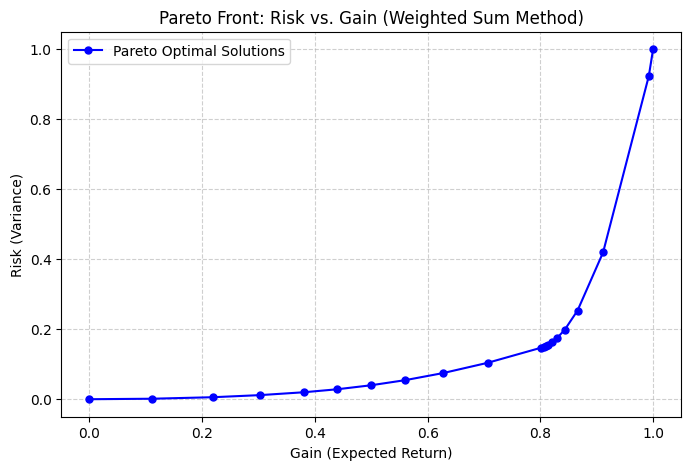

In [14]:
n_ = 21

WSM = WeightedSumMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
wsm_pareto_front, weights = WSM.optimize()
WSM.plot_pareto_front()

#### **4.2. Epsilon Constraint Method**

##### 4.2.1. Plotting Pareto Front for different number of points:

Number of points in the Pareto Front: 11


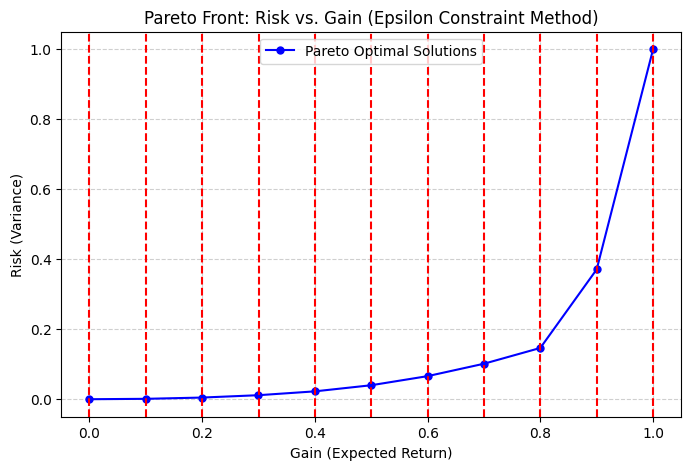

Number of points in the Pareto Front: 21


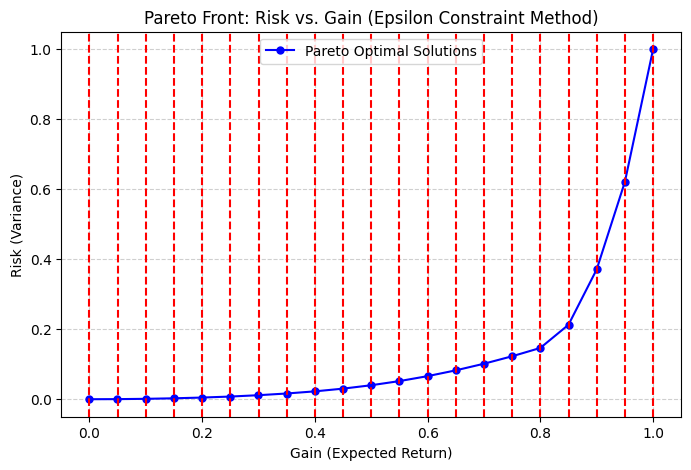

Number of points in the Pareto Front: 51


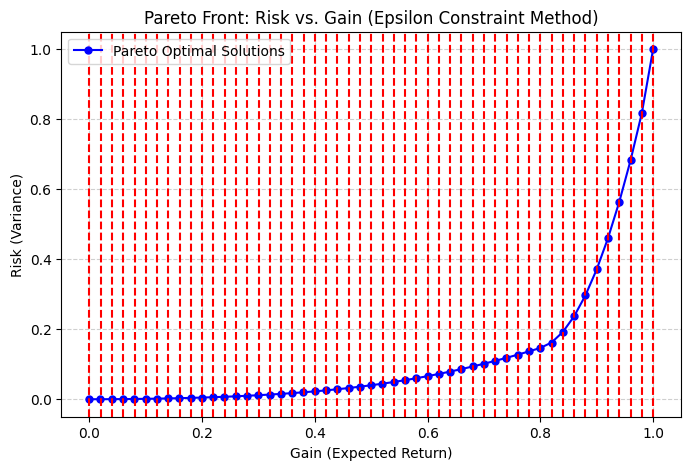

Number of points in the Pareto Front: 101


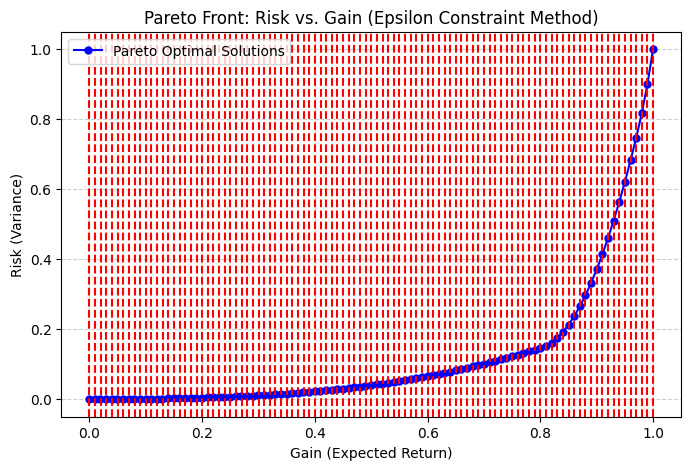

In [15]:
for n_ in [11, 21, 51, 101]:
    ECM = EpsilonConstraintMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
    ecm_pareto_front, epsilons = ECM.optimize()
    print(f'Number of points in the Pareto Front: {n_}')
    ECM.plot_pareto_front()

In ECM, the points are better distributed and because of that, there is no elbow. Pareto Front with 100 points is very cluttered, since we draw the red lines. Analgously to WSM, there is no sense to draw more points on the plot. Execution time of the algorithm is better for ECM (more less 2x, beacuse searched solution space is smaller), but execution time is not the most important factor here.

##### 4.2.2. Measuring time:

In [49]:
%%timeit
for n_ in [11, 21, 51, 101]:
    ECM = EpsilonConstraintMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
    ecm_pareto_front, epsilons = ECM.optimize()

79.1 ms ± 597 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


##### 4.2.3. Calculating number of unique solutions for n_ = 1001

In [18]:
ECM = EpsilonConstraintMethodOptimizer(expected_returns, risks_matrix, n_points=1001)
ecm_pareto_front, epsilons = ECM.optimize()
print(f'Number of unique solutions for WSM: {calculate_unique_solutions(wsm_pareto_front)}')

Number of unique solutions for WSM: 1001


##### 4.2.4. Plot Pareto Front for 20 points

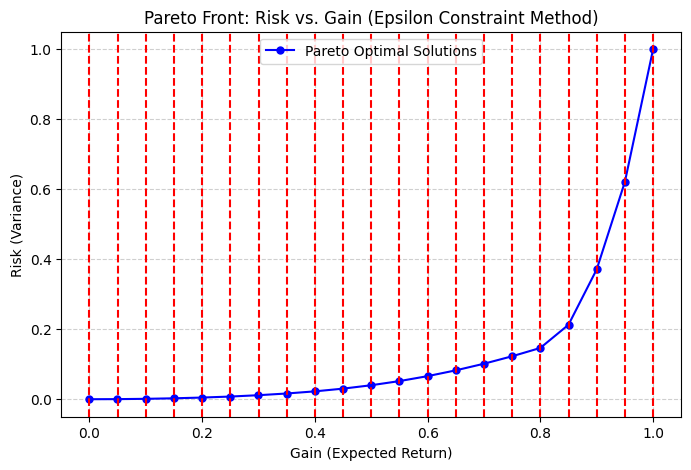

In [19]:
n_ = 21

ECM = EpsilonConstraintMethodOptimizer(expected_returns, risks_matrix, n_points=n_)
ecm_pareto_front, epsilons = ECM.optimize()
ECM.plot_pareto_front()

### **4.3. Choosing the strategy**

Since the amount of data is limited, we don't want to risk too much - thus, we would like to choose the strategy that is very safe (i. e. in terms of normalized data, we minimize the risk but we want the gain to be at least X) so we chose the strategy with gain >= 0.05 (after normalization). This strategy gives us a possibility to make a hard constraint on the gain as well as limit the risk as much as possible. Also solution produced by WSM is presented for documentary purposes.

In [20]:
# WSM
wsm_sol = WSM.choose_strategy(0.9) # High weight assigned to risk = safest portfolio
wsm_sol

(np.float64(1.1670759686604844e-05),
 np.float64(3.215014013149204),
 array([6.44938461e-02, 1.23555419e-02, 2.90876173e-10, 2.59862568e-09,
        5.21278668e-02, 4.64869797e-09, 1.17001758e-01, 5.97068574e-03,
        1.42827145e-02, 2.02786339e-09, 7.58203363e-03, 9.74652762e-08,
        2.72279131e-02, 2.27911880e-03, 7.99709206e-02, 7.64683277e-02,
        8.83295509e-06, 2.13908098e-02, 1.98862966e-01, 3.19976557e-01]))

In [52]:
# ECM
ecm_sol = ECM.choose_strategy(0.05)
ecm_sol

(4.3145972296195235e-06,
 1.516680201566861,
 array([2.52634990e-02, 1.70286524e-02, 2.46243376e-04, 3.05290889e-05,
        4.87298395e-02, 3.45021071e-04, 1.06357057e-01, 8.20657043e-03,
        1.70653615e-02, 1.46289656e-03, 3.50882425e-03, 2.49333605e-01,
        1.01555996e-02, 1.15630724e-02, 5.58586066e-02, 9.70139256e-02,
        2.52710694e-02, 7.52694192e-03, 9.82921542e-02, 2.16740532e-01]))

### **4.4. Write solutions to a file**

Since we know thhe strategy that we want to use, the only thing to do is export them to .txt file consistent with the requirements

In [ ]:
write_solutions(ecm_sol, os.path.join(DIR_path, '..', '156035_156045.txt'))